In [1]:
pip install torch torchvision matplotlib scikit-learn

Using device: cuda


100%|██████████| 94.3M/94.3M [00:00<00:00, 300MB/s]


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of images: 27000
Epoch [1/10] Train Loss: 1.0574, Train Acc: 0.6371 | Val Loss: 0.8392, Val Acc: 0.7081
Epoch [2/10] Train Loss: 0.6996, Train Acc: 0.7543 | Val Loss: 0.5491, Val Acc: 0.8049
Epoch [3/10] Train Loss: 0.5815, Train Acc: 0.7977 | Val Loss: 0.5855, Val Acc: 0.7946
Epoch [4/10] Train Loss: 0.5246, Train Acc: 0.8183 | Val Loss: 0.8583, Val Acc: 0.7393
Epoch [5/10] Train Loss: 0.4680, Train Acc: 0.8367 | Val Loss: 0.5058, Val Acc: 0.8402
Epoch [6/10] Train Loss: 0.4243, Train Acc: 0.8551 | Val Loss: 0.3857, Val Acc: 0.8674
Epoch [7/10] Train Loss: 0.3851, Train Acc: 0.8693 | Val Loss: 0.3896, Val Acc: 0.8726
Epoch [8/10] Train Loss: 0.3485, Train Acc: 0.8803 | Val Loss: 0.7386, Val Acc: 0.7817
Epoch [9/10] Train Loss: 0.3231, Train Acc: 0.8914 | Val Loss: 0.8577, Val Acc: 0.7840
Epoch [10/10] Train Loss: 0.2775, Train Acc: 0.

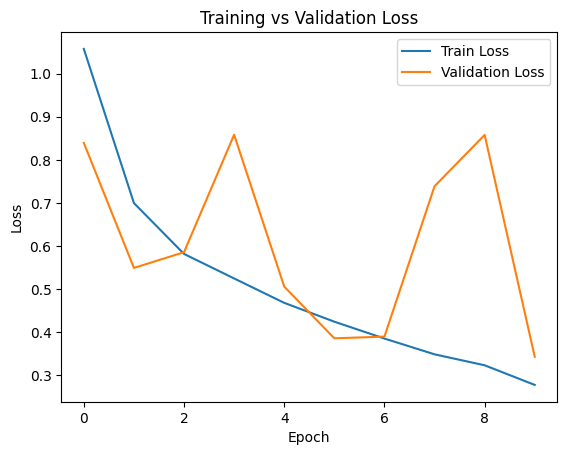

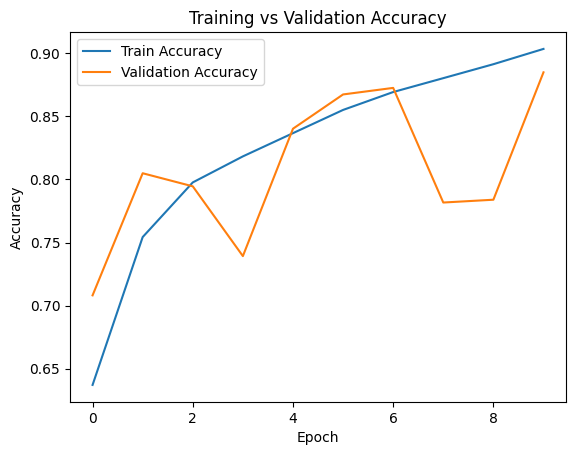

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import EuroSAT
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# -----------------------------
# 1. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Transform satellite images
# -----------------------------
# EuroSAT RGB images are 64x64.
# We normalize the RGB channels so the CNN trains more smoothly.
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------------
# 3. Download and load dataset
# -----------------------------
dataset = EuroSAT(
    root="./data",
    download=True,
    transform=transform
)

class_names = dataset.classes
print("Classes:", class_names)
print("Number of images:", len(dataset))

# -----------------------------
# 4. Train / validation / test split
# -----------------------------
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# -----------------------------
# 5. CNN model
# -----------------------------
class SatelliteCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SatelliteCNN, self).__init__()

        self.features = nn.Sequential(
            # Input: 3 x 64 x 64

            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Output: 32 x 32 x 32

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Output: 64 x 16 x 16

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Output: 128 x 8 x 8
        )

        self.regressor_or_classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor_or_classifier(x)
        return x

model = SatelliteCNN(num_classes=len(class_names)).to(device)

# -----------------------------
# 6. Loss function and optimizer
# -----------------------------
# Since EuroSAT is classification, we use CrossEntropyLoss.
# For soil moisture regression, we would change this to MSELoss.
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# -----------------------------
# 7. Training function
# -----------------------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# -----------------------------
# 8. Validation function
# -----------------------------
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_predictions, all_labels

# -----------------------------
# 9. Train model
# -----------------------------
num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )

    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

# -----------------------------
# 10. Test model
# -----------------------------
test_loss, test_acc, y_pred, y_true = evaluate(
    model, test_loader, criterion
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -----------------------------
# 11. Plot training curves
# -----------------------------
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()